In [6]:
import pandas as pd
import os
from nilearn import plotting
from nilearn.glm.second_level import SecondLevelModel
from nilearn.glm import threshold_stats_img
from pathlib import Path
from nilearn.image import resample_to_img, math_img
from nilearn import plotting, image, datasets
from scipy.ndimage import label
import numpy as np
import matplotlib.pyplot as plt
from atlasreader import create_output

In [2]:
virtueORvice = 'virtues' # vices, virtues
whichStory = "shapes"
whichStory1 = "shapessocial"  
whichStory2 = "shapesphysical"  

whichFoundation = '3' # 1 to 7

# 1 to 7 maps onto the following foundations MAC:
# 1 = deference
# 2 = fairness
# 3 = family
# 4 = group
# 5 = heroism
# 6 = property
# 7 = reciprocity

# output directory
base_dir1 = os.path.expanduser(
    "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/"
)

output_dir = Path(f"{base_dir1}{virtueORvice}/vsBaseline/compareGroups/{whichFoundation}/{whichStory}/")

# make the output directory if it does not exist: 
output_dir.mkdir(parents=True, exist_ok=True)

# results directory

if virtueORvice == 'virtues':
    virtueORviceDataFolder = '7_MAC'

if virtueORvice == 'vices':
    virtueORviceDataFolder = '7_MAC_V'

base_dir2 = os.path.expanduser(
    "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/processed_first_level_per_sentence/"
)

results_dir_affair = Path(f"{base_dir2}{whichStory1}/{virtueORviceDataFolder}/VsBaseline/")
results_dir_paranoia = Path(f"{base_dir2}{whichStory2}/{virtueORviceDataFolder}/VsBaseline/")

In [3]:
files_social = sorted(
    results_dir_affair.glob(f"*foundation{whichFoundation}_vsBaseline.nii.gz")
)

print(f"Found {len(files_social)} images.")


Found 59 images.


In [4]:
files_physical = sorted(
    results_dir_paranoia.glob(f"*foundation{whichFoundation}_vsBaseline.nii.gz")
)

print(f"Found {len(files_physical)} images.")

Found 59 images.


In [7]:

# 2. Convert PosixPaths → strings 
files_social = [str(f) for f in files_social]
files_physical = [str(f) for f in files_physical]

# 3. resample to same reference image
ref = files_social[0]
all_imgs = files_social + files_physical
imgs_resampled = [resample_to_img(img, ref) for img in all_imgs]

# Split back into conditions after resampling
n_subs = len(files_social)
imgs_social = imgs_resampled[:n_subs]
imgs_physical = imgs_resampled[n_subs:]

# 4. Compute within-subject difference maps (social - physical)
diff_imgs = [
    math_img("img1 - img2", img1=s, img2=p)
    for s, p in zip(imgs_social, imgs_physical)
]

# 5. design matrix
design_matrix = pd.DataFrame({'intercept': [1] * len(diff_imgs)})

# 6. Initialize and fit the second-level model
second_level_model = SecondLevelModel()
second_level_model = second_level_model.fit(diff_imgs, design_matrix=design_matrix)

# 7. Compute contrasts
# (a) Social > Physical
z_map_social_over_physical = second_level_model.compute_contrast(
    'intercept', output_type='z_score'
)
z_map_social_over_physical.to_filename(
    str(output_dir) + '/social_over_physical_zmap.nii.gz'
)

# (b) Physical > Social
z_map_physical_over_social = second_level_model.compute_contrast(
    '-intercept', output_type='z_score'
)
z_map_physical_over_social.to_filename(
    str(output_dir) + '/physical_over_social_zmap.nii.gz'
)


/var/folders/2b/y7vqbp2s3slchmzyrsz69p1m0000gn/T/ipykernel_12132/2440686672.py:8: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  imgs_resampled = [resample_to_img(img, ref) for img in all_imgs]


In [9]:
# do fdr correction
thresholded_map, threshold_1 = threshold_stats_img(
    z_map_social_over_physical, alpha=0.05, height_control='fdr'
)
thresholded_map.to_filename(str(output_dir)+'/social_over_physical_FDR05.nii.gz')

print(threshold_1)

create_output(str(output_dir)+'/social_over_physical_FDR05.nii.gz',
              cluster_extent=10,direction="pos",outdir=str(output_dir))


# do fdr correction
thresholded_map, threshold_2 = threshold_stats_img(
    z_map_physical_over_social, alpha=0.05, height_control='fdr'
)
thresholded_map.to_filename(str(output_dir)+'/physical_over_social_FDR05.nii.gz')

print(threshold_2)

create_output(str(output_dir)+'/physical_over_social_FDR05.nii.gz',
              cluster_extent=10,direction="pos",outdir=str(output_dir))

3.1121799062022952


/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)


3.1121799062022952


/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)


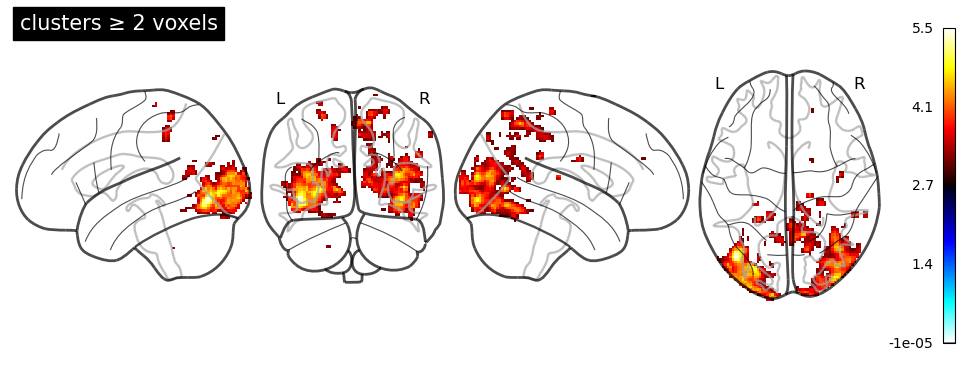

In [10]:
stat_img = image.load_img(str(output_dir)+'/social_over_physical_FDR05.nii.gz')

# Extract data and affine
data = stat_img.get_fdata()
affine = stat_img.affine

# Label connected clusters
labeled_array, num_features = label(data > 0)  # detects all nonzero clusters

# Keep only clusters with ≥2 voxels
filtered_data = np.zeros_like(data)
for cluster_idx in range(1, num_features + 1):
    cluster_mask = labeled_array == cluster_idx
    if cluster_mask.sum() >= 2:
        filtered_data[cluster_mask] = data[cluster_mask]

# Create filtered image
filtered_img = image.new_img_like(stat_img, filtered_data)

# Plot
display = plotting.plot_glass_brain(
    filtered_img,
    colorbar=True,
    display_mode='lyrz',
    plot_abs=False,
    cmap='cold_hot',
    title='clusters ≥ 2 voxels'
)

# Save as PNG
display.savefig(str(output_dir)+'/social_over_physical_fdr05.png', dpi=300)  

plt.show()

display.close()

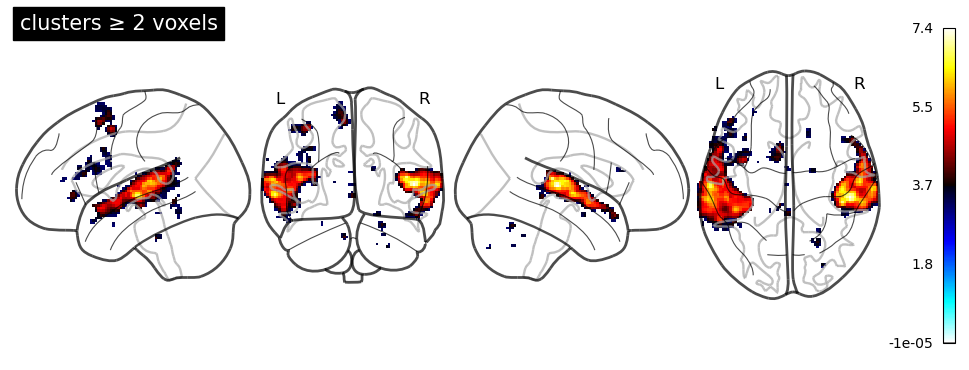

In [11]:
stat_img = image.load_img(str(output_dir)+'/physical_over_social_FDR05.nii.gz')

# Extract data and affine
data = stat_img.get_fdata()
affine = stat_img.affine

# Label connected clusters
labeled_array, num_features = label(data > 0)  # detects all nonzero clusters

# Keep only clusters with ≥2 voxels
filtered_data = np.zeros_like(data)
for cluster_idx in range(1, num_features + 1):
    cluster_mask = labeled_array == cluster_idx
    if cluster_mask.sum() >= 2:
        filtered_data[cluster_mask] = data[cluster_mask]

# Create filtered image
filtered_img = image.new_img_like(stat_img, filtered_data)

# Plot
display = plotting.plot_glass_brain(
    filtered_img,
    colorbar=True,
    display_mode='lyrz',
    plot_abs=False,
    cmap='cold_hot',
    title='clusters ≥ 2 voxels'
)

# Save as PNG
display.savefig(str(output_dir)+'/physical_over_social_fdr05.png', dpi=300)  

plt.show()

display.close()